In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from scipy.stats import beta 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns 

# 0 - Cleaning

In [2]:
# load data 
cpi = pd.read_csv('Data/common_player_info.csv')
game = pd.read_csv('Data/game.csv')
ls = pd.read_csv('Data/line_score.csv')
os = pd.read_csv('Data/other_stats.csv')

### Player Info 

The only cleaning done here is dropping unnecessary columns.

In [3]:
# rename person_id to player_id in cpi for better readability 
cpi2 = cpi.rename(columns={'person_id': 'player_id'})

# drop unnecessary columns in cpi2
player_df = cpi2.drop(columns=['display_last_comma_first', 'display_fi_last'])

# ensure is unique players 
player_df['player_id'].is_unique

True

### Game Info 

To make one combined game dataset, we are merging the game, line score, and other stats datasets. This will give us all of the stats in for the games in one dataset, which will make it easier for analysis.

In [4]:
# renaming 'All star' season type values to be standardized 
game2 = game.copy() 
game2['season_type'] = game2['season_type'].replace('All Star', 'All-Star')
print("Seasons type", game2['season_type'].value_counts())

# dropping duplicate game ids in game df
game2 = game2.drop_duplicates(subset='game_id', keep='first')
print("Game IDs unique:", game2['game_id'].is_unique)

Seasons type Regular Season    60192
Playoffs           3842
Pre Season         1536
All-Star            128
Name: season_type, dtype: int64
Game IDs unique: True


In [5]:
# dropping duplicate game ids in line score df
ls2 = ls.drop_duplicates(subset='game_id', keep='first')
print("Line Score Game IDs unique:", ls2['game_id'].is_unique)

Line Score Game IDs unique: True


In [6]:
# printing duplicated columns in game3 and ls2 to drop before merging 
print('Similar columns:')
for col in game2.columns:
    if col in ls2.columns:
        print(col)

# dropping all similar columns EXCEPT game_id fro ls2 (bc is smaller df) 
ls2 = ls2.drop(columns=['team_id_home', 'team_abbreviation_home', 'pts_home', 'team_id_away', 'team_abbreviation_away', 'pts_away'])

# verify dropping 
print('\nChecking columns:')
for col in game2.columns:
    if col in ls2.columns:
        print(col)

Similar columns:
team_id_home
team_abbreviation_home
game_id
pts_home
team_id_away
team_abbreviation_away
pts_away

Checking columns:
game_id


In [7]:
# merging game2 and ls2 on game_id to have one game df
game_df = pd.merge(game2, ls2, on='game_id', how='inner')
print(f'game2 shape: {game2.shape}')
print(f'ls2 shape: {ls2.shape}')
print(f'game_df shape: {game_df.shape}')
game_df 

game2 shape: (65642, 55)
ls2 shape: (58013, 37)
game_df shape: (58013, 91)


,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,...,pts_ot1_away,pts_ot2_away,pts_ot3_away,pts_ot4_away,pts_ot5_away,pts_ot6_away,pts_ot7_away,pts_ot8_away,pts_ot9_away,pts_ot10_away
0,21946,1610610035,HUS,Toronto Huskies,24600001,1946-11-01 00:00:00,HUS vs. NYK,L,0,25.0,...,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21946,1610610034,BOM,St. Louis Bombers,24600003,1946-11-02 00:00:00,BOM vs. PIT,W,0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21946,1610610032,PRO,Providence Steamrollers,24600002,1946-11-02 00:00:00,PRO vs. BOS,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21946,1610610025,CHS,Chicago Stags,24600004,1946-11-02 00:00:00,CHS vs. NYK,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21946,1610610028,DEF,Detroit Falcons,24600005,1946-11-02 00:00:00,DEF vs. WAS,L,0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58008,42022,1610612743,DEN,Denver Nuggets,42200402,2023-06-04 00:00:00,DEN vs. MIA,L,240,39.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58009,42022,1610612748,MIA,Miami Heat,42200403,2023-06-07 00:00:00,MIA vs. DEN,L,240,34.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58010,42022,1610612748,MIA,Miami Heat,42200404,2023-06-09 00:00:00,MIA vs. DEN,L,240,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58011,42022,1610612743,DEN,Denver Nuggets,42200405,2023-06-12 00:00:00,DEN vs. MIA,W,240,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
# dropping irrelevant columns in other_stats 
os2 = os.drop(columns=['league_id'])

# dropping duplicate game ids in other stats df
os2 = os2.drop_duplicates(subset='game_id', keep='first')
print("Other_stats Game IDs unique:", os2['game_id'].is_unique)

Other_stats Game IDs unique: True


In [9]:
# printing duplicated columns in game_df and os2 to drop before merging 
print('Similar columns:')
for col in game_df.columns:
    if col in os2.columns:
        print(col)

# dropping all similar columns EXCEPT game_id fro ls2 (bc is smaller df) 
os2 = os2.drop(columns=['team_id_home', 'team_abbreviation_home', 'team_id_away', 'team_abbreviation_away'])

# # verify dropping 
print('\nChecking columns:')
for col in game_df.columns:
    if col in os2.columns:
        print(col)

Similar columns:
team_id_home
team_abbreviation_home
game_id
team_id_away
team_abbreviation_away

Checking columns:
game_id


In [10]:
# merging game_df and os2 on game_id to have one game df with all stats
final_game_df = pd.merge(game_df, os2, on='game_id', how='inner')
print(f'game_df shape: {game_df.shape}')
print(f'os2 shape: {os2.shape}')
print(f'final_game_df shape: {final_game_df.shape}')
final_game_df

game_df shape: (58013, 91)
os2 shape: (28261, 21)
final_game_df shape: (28261, 111)


,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,...,pts_off_to_home,team_city_away,pts_paint_away,pts_2nd_chance_away,pts_fb_away,largest_lead_away,team_turnovers_away,total_turnovers_away,team_rebounds_away,pts_off_to_away
0,21996,1610612747,LAL,Los Angeles Lakers,29600012,1996-11-01 00:00:00,LAL vs. PHX,W,240,31.0,...,NaN,Los Angeles,42,10,13,19,0.0,23.0,11.0,NaN
1,21996,1610612748,MIA,Miami Heat,29600005,1996-11-01 00:00:00,MIA vs. ATL,W,240,35.0,...,NaN,Miami,32,15,14,16,1.0,19.0,6.0,NaN
2,21996,1610612751,NJN,New Jersey Nets,29600002,1996-11-01 00:00:00,NJN vs. CLE,L,240,23.0,...,NaN,New Jersey,26,16,4,2,1.0,22.0,12.0,NaN
3,21996,1610612765,DET,Detroit Pistons,29600007,1996-11-01 00:00:00,DET vs. IND,W,240,32.0,...,NaN,Detroit,30,14,7,9,2.0,19.0,10.0,NaN
4,21996,1610612744,GSW,Golden State Warriors,29600013,1996-11-01 00:00:00,GSW vs. LAC,L,240,27.0,...,NaN,Golden State,30,9,2,6,0.0,20.0,7.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28256,42022,1610612743,DEN,Denver Nuggets,42200401,2023-06-01 00:00:00,DEN vs. MIA,W,240,40.0,...,13.0,Denver,46,7,9,24,0.0,10.0,7.0,9.0
28257,42022,1610612743,DEN,Denver Nuggets,42200402,2023-06-04 00:00:00,DEN vs. MIA,L,240,39.0,...,19.0,Miami,34,11,5,12,0.0,11.0,4.0,23.0
28258,42022,1610612748,MIA,Miami Heat,42200403,2023-06-07 00:00:00,MIA vs. DEN,L,240,34.0,...,8.0,Denver,60,14,11,21,1.0,14.0,7.0,17.0
28259,42022,1610612748,MIA,Miami Heat,42200404,2023-06-09 00:00:00,MIA vs. DEN,L,240,35.0,...,8.0,Miami,46,9,14,3,1.0,15.0,9.0,17.0


# 1 - Problem Formulation

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

**Predictive Task:** Can we predict whether the home team will win an NBA game?

**The Difference Between Inferential and Predictive Here:** In the inferential question, we are exploring how a characteristic of NBA games, the "home-court advantage", exists and how it has changed over time. Specifically, we are estimating the population parameter π, the true probability that a home team wins an NBA game, and assessing whether it differs from 0.5 and whether it has changed in the modern era. There is no decision made about any future or additional game in the inferential sections, but rather conclusions are drawn about this long-run probability using historical data from existing and finished NBA games.

In contrast, the prediction task asks if we can build a model and use it to decide, based on the games' features, whether a home team is likely to win an NBA game. The target variable is binary, $Y ∈ {0, 1\\}$, where $Y = 1$ represents a home team win and $Y=0$ represents a loss. Rather than estimating a population parameter, the predictive task focuses on evaluating how well the model can generalize to games that have not yet occurred. or may happen in the future.

So the inferential question addresses the underlying home-court advantage as a population-level parameter and whether it has changed over time, while the predictive question addresses whether we can accurately classify the outcome of future games.

### SECTIONS:

1. Problem Formulation (hybrid)
2. Likelihood and Estimation (inferential)
3. Frequentist Inference (inferential)
4. Bayesian Estimation (inferential)
5. Resampling and Simulation (inferential)
6. Prediction and Model Evaluation (prediction)
7. Regularization and Shrinkage (prediction)
8. Inference vs Prediction Reflection (inferential & prediction comparison)

# 2- Likelihood and MLE 

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

**Parameter of Interest:** π = true home-win probability

**Estimator:** p̂ = (number of home wins) / (total games)

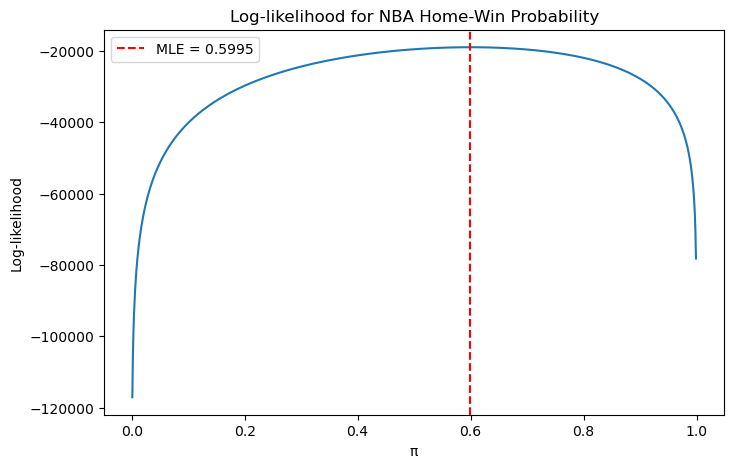

In [11]:
# making a copy of game df to keep everything clean 
df = final_game_df.copy() 

df['home_win'] = (df['wl_home'] == 'W').astype(int)
n = len(df) # Total Games
w = df['home_win'].sum() # Home Wins
pi_hat = w / n

# Log-likelihood function
def log_likelihood(pi):
    return w * np.log(pi) + (n - w) * np.log(1 - pi)

# Grid of pi values
pi_grid = np.linspace(0.001, 0.999, 1000)
ll = log_likelihood(pi_grid)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(pi_grid, ll)
plt.axvline(pi_hat, color='red', linestyle='--', label=f'MLE = {pi_hat:.4f}')
plt.xlabel('π')
plt.ylabel('Log-likelihood')
plt.title('Log-likelihood for NBA Home-Win Probability')
plt.legend()
plt.show()

# 3 - Frequentist Estimation and Testing 

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

**Parameter of Interest:** π = true home-win probability

**Estimator:** p̂ = (number of home wins) / (total games)

### Data Loading

In [12]:
# copying final game df to keep everything clean for inference
game_df = final_game_df.copy()

#Filter to Regular Season games only for clean inference
reg_season = game_df[game_df['season_type'] == 'Regular Season'].copy()
#setting up the target of win and loss
# Binary outcome: 1 = home win, 0 = home loss
reg_season['home_win'] = (reg_season['wl_home'] == 'W').astype(int)
reg_season['pt_diff']  = reg_season['pts_home'] - reg_season['pts_away']

# Extract season year from season_id, which is found in last four digits
reg_season['season_year'] = reg_season['season_id'].astype(str).str[-4:].astype(int)
#creating key variables for the total games, wins and probability
n_total = len(reg_season)
n_wins = reg_season['home_win'].sum()
p_hat = n_wins / n_total

### Sampling Distribution Reasoning 

We model each game as an independent Bernoulli trial with unknown success probability π.
The MLE is p̂ = X/n. Using Centeral Limit Theorem

se mle: 0.0030554960464515744
se null: 0.003115642781973398


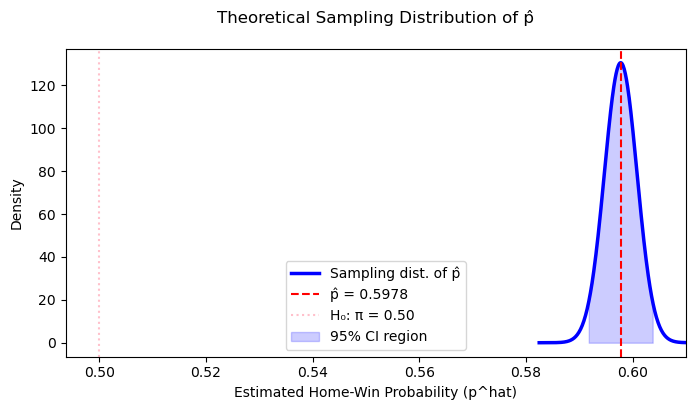

In [13]:
#theoretical standard error under MLE
se_mle = np.sqrt(p_hat * (1 - p_hat) / n_total)

#standard error under null, pi = .5
se_null = np.sqrt(0.5 * 0.5 / n_total)

#checking results
print("se mle:", se_mle)
print("se null:", se_null)

# Visualize the theoretical sampling distribution
fig, ax = plt.subplots(figsize=(8, 4))
#setting the graph proportions right for x and y
x = np.linspace(p_hat - 5 * se_mle, p_hat + 5 * se_mle, 300)
y = stats.norm.pdf(x, p_hat, se_mle)
ax.set_xlim(p_hat - 5 * se_mle, p_hat + 5 * se_mle)
ax.set_xlim(min(0.5 - 2*se_null, p_hat - 4*se_mle),
            max(0.5 + 2*se_null, p_hat + 4*se_mle))
#plotting
ax.plot(x, y, color='blue', lw=2.5, label='Sampling dist. of p̂')
ax.axvline(p_hat, color='red', ls='--', lw=1.5, label=f'p̂ = {p_hat:.4f}')
ax.axvline(0.5, color='pink', ls=':', lw=1.5, label='H₀: π = 0.50')

#shade 95% region
ci_lo = p_hat - 1.96 * se_mle
ci_hi = p_hat + 1.96 * se_mle
x_shade = np.linspace(ci_lo, ci_hi, 300)
ax.fill_between(x_shade, stats.norm.pdf(x_shade, p_hat, se_mle),
                alpha=0.2, color='blue', label='95% CI region')
#labeling
ax.set_xlabel('Estimated Home-Win Probability (p^hat)')
ax.set_ylabel('Density')
ax.set_title('Theoretical Sampling Distribution of p̂\n')

ax.legend()
plt.show()

### Confidence Intervals 

**Using boostraping:** resample the data, refit the model, repeat many times, then take the 2.5th and 97.5th percentiles of the resulting distribution

Bootstrap 95% CI for pi: (0.591830, 0.603674)


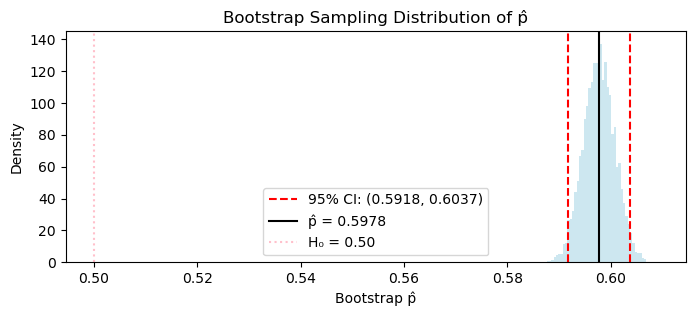

In [14]:
#Bootstrap CI for home-win probability
#setting n size
n_boot = 10000
boot_props = np.zeros(n_boot)

for i in range(n_boot):
    #resample wins
    boot_sample = np.random.binomial(n_total, p_hat)
    #refit "model" (p̂)
    boot_props[i] = boot_sample / n_total

#95% bootstrap CI
boot_lo = np.percentile(boot_props, 2.5)
boot_hi = np.percentile(boot_props, 97.5)

print(f'Bootstrap 95% CI for pi: ({boot_lo:.6f}, {boot_hi:.6f})')

# Plot
fig, ax = plt.subplots(figsize=(8, 3))
#setting boostrap and coolors
ax.hist(boot_props, bins=50, color='lightblue', alpha=0.6, density=True)
ax.axvline(boot_lo, color='red', ls='--', lw=1.5, label=f'95% CI: ({boot_lo:.4f}, {boot_hi:.4f})')
ax.axvline(boot_hi, color='red', ls='--', lw=1.5)
ax.axvline(p_hat,   color='black', ls='-',  lw=1.5, label=f'p̂ = {p_hat:.4f}')
ax.axvline(0.5,     color='pink', ls=':', lw=1.5, label='H₀ = 0.50')
#labeling
ax.set_xlabel('Bootstrap p̂')
ax.set_ylabel('Density')
ax.set_title('Bootstrap Sampling Distribution of p̂')
#printing
ax.legend()
plt.show()

**Theory CI: Wald**

Nearly identical to bootstrap: n is large enough that the CLT has kicked in fully.

The 95% confidence interval suggests that the true home-win probability π falls between 0.5918 and 0.6038. Since the entire interval is above 0.50, this gives strong evidence that home teams win more than half the time.

In [15]:
ci_lo = p_hat - 1.96 * se_mle
ci_hi = p_hat + 1.96 * se_mle

print(f'Wald 95% CI for pi: ({ci_lo:.6f}, {ci_hi:.6f})')

Wald 95% CI for pi: (0.591782, 0.603760)


### Hypothesis Testing 

**Test 1: Does a Home-Court Advantage Exist?**

H_0: pi = 0.5

H_1: pi > 0.5

Interpretation: With Z = 32.0 and p around 0, we reject H0 at every conventional significance level. There is overwhelming evidence that NBA home teams win more than 50% of regular season games (p̂ = 0.5978).

In [16]:
# One-sided z-test: H1: pi > 0.5
z_stat, p_val = proportions_ztest(n_wins, n_total, value=0.5, alternative='larger')
print(f'Test statistic Z  = {z_stat:.4f}')
print(f'P-value           = {p_val:.2e}')
print(f'Decision (α=0.05): {"Reject H0" if p_val < 0.05 else "Fail to reject H0"}')

Test statistic Z  = 31.9985
P-value           = 5.72e-225
Decision (α=0.05): Reject H0


**Test 2: Has Home-Court Advantage Declined in the Modern Era?**

The 2019–2021 seasons (COVID bubble, restricted attendance) may have reduced home-court advantage. We test whether the pre-2019 and post-2018 home-win rates differ.

H_0: pi_new = pi_old

H_1: pi_new /= pi_old

In [17]:
#Split into pre-2019 (traditional) and 2019+ (modern/bubble) era
era_old = reg_season[reg_season['season_year'] <  2019]
era_new = reg_season[reg_season['season_year'] >= 2019]
#calculating p_hat of new and old eras
n_old, wins_old = len(era_old), era_old['home_win'].sum()
n_new, wins_new = len(era_new), era_new['home_win'].sum()
p_old = wins_old / n_old
p_new = wins_new / n_new

# Two-sample z-test for proportions
z2, p2 = proportions_ztest([wins_old, wins_new], [n_old, n_new], alternative='two-sided')

#CIs for each era
ci_old = proportion_confint(wins_old, n_old, method='wilson')
ci_new = proportion_confint(wins_new, n_new, method='wilson')

print(f'Z = {z2:.4f},  p-value = {p2:.4f}')
print(f'Decision (α=0.05): {"Reject H0" if p2 < 0.05 else "Fail to reject H0"}')
print()
print(f'Pre-2019 95% CI: ({ci_old[0]:.4f}, {ci_old[1]:.4f})')
print(f'2019+ 95% CI: ({ci_new[0]:.4f}, {ci_new[1]:.4f})')

Z = 5.3163,  p-value = 0.0000
Decision (α=0.05): Reject H0

Pre-2019 95% CI: (0.5981, 0.6111)
2019+ 95% CI: (0.5437, 0.5749)


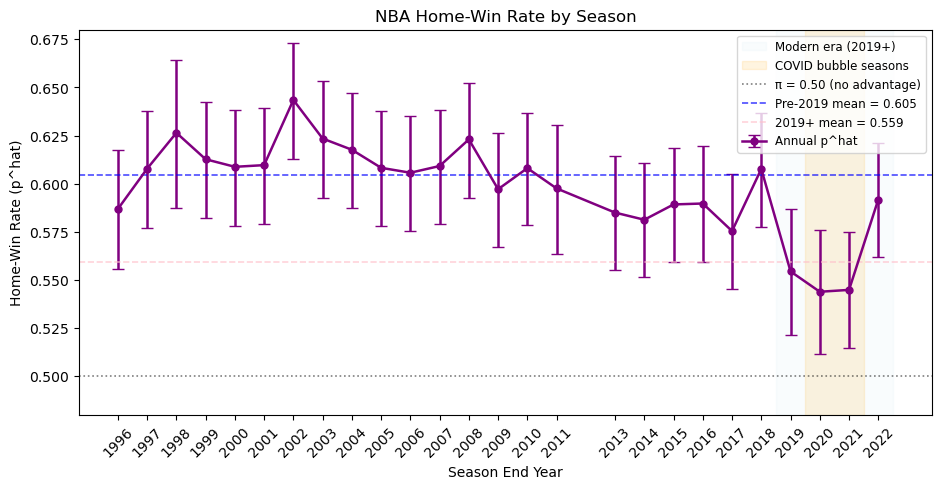

In [18]:
#Visualize home-win rate by season with era bands
annual = reg_season.groupby('season_year')['home_win'].agg(['mean','count','sum']).reset_index()
annual.columns = ['year','p_hat','n','wins']

#Adding CI per season
annual['ci_lo'] = annual.apply(lambda r: proportion_confint(r['wins'], r['n'], method='wilson')[0], axis=1)
annual['ci_hi'] = annual.apply(lambda r: proportion_confint(r['wins'], r['n'], method='wilson')[1], axis=1)

fig, ax = plt.subplots(figsize=(11, 5))

#Adding era shading
ax.axvspan(2018.5, annual['year'].max() + 0.5, alpha=0.07, color='lightblue', label='Modern era (2019+)')
ax.axvspan(2019.5, 2021.5, alpha=0.12, color='orange', label='COVID bubble seasons')

# Adding error bars
ax.errorbar(annual['year'], annual['p_hat'],
            yerr=[annual['p_hat'] - annual['ci_lo'], annual['ci_hi'] - annual['p_hat']],
            fmt='o-', color='purple', capsize=4, ms=5, lw=1.8, label='Annual p^hat')

# Reference lines
ax.axhline(0.5,    color='black',            ls=':',  lw=1.2, alpha=0.5, label='π = 0.50 (no advantage)')
ax.axhline(p_old,  color='blue',  ls='--', lw=1.2, alpha=0.7, label=f'Pre-2019 mean = {p_old:.3f}')
ax.axhline(p_new,  color='pink', ls='--', lw=1.2, alpha=0.7, label=f'2019+ mean = {p_new:.3f}')

ax.set_xlabel('Season End Year')
ax.set_ylabel('Home-Win Rate (p^hat)')
ax.set_title('NBA Home-Win Rate by Season')
ax.set_ylim(0.48, 0.68)
ax.legend(fontsize=8.5, loc='upper right')
ax.set_xticks(annual['year'])
ax.tick_params(axis='x', rotation=45)
plt.show()

# 4 - Bayesian Analysis

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

**Parameter of Interest:** π = true home-win probability (treat as random variable and is originally unknown)

**Model:** Each NBA game is modeled as a Bernoulli trial with success probability π. The total number of home wins follows a Binomial distribution.

**Prior:** We assign a Beta(1,1) prior to π, representing a uniform prior belief.

**Posterior:** After observing the data, the posterior becomes = (π | data ~ Beta(1 + wins, 1 + losses))

### Data Loading

*game_df, regular season filtering, and key variables for total games/wins/probability is used from above Section 3 code* 

### Posterior Inference 

**Model Training (Beta-Binomial)**

* Why beta-binomial? : outcome is binary with 1 (home win) and 0 (home loss)
* Unknown parameter (π): the true home-win probability

In [19]:
n_losses = n_total - n_wins

# prior: Beta(1,1) - beta binomial - This is a uniform prior, meaning we do not strongly favor any home-win probability before seeing data
alpha_prior = 1 # will be number of wins - act like saw one win
beta_prior = 1 # will be number of losses - act like saw one loss

# if alpha > beta -> greater than 0.5
# if alpha < beta -> less than 0.5
# more data -> more confident with more narrow CI
# alpha around= beta -> centered at 0.5

# posterior update for beta-binomial
alpha_post = alpha_prior + n_wins # update with real win data
beta_post = beta_prior + n_losses # update with real loss data

# posterior mean
posterior_mean = alpha_post / (alpha_post + beta_post) # wins / total

# 95% credible interval (CI)
credible_interval = beta.ppf([0.025, 0.975], alpha_post, beta_post)

# probability that home-court advantage exists
prob_home_advantage = 1 - beta.cdf(0.5, alpha_post, beta_post) # What is chance home teams are actually better than 50%?

# print all info just gained above
print("--- Prior: Beta(1, 1) - the beta-binomial model ---\n")

print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"Posterior mean: {posterior_mean}")
print(f"95% credible interval: ({credible_interval[0]}, {credible_interval[1]})")
print(f"P( pi > 0.5 | data ): {prob_home_advantage:}")

--- Prior: Beta(1, 1) - the beta-binomial model ---

Posterior: Beta(15396, 10360)
Posterior mean: 0.5977636278925299
95% credible interval: (0.5917681577814002, 0.6037447173113957)
P( pi > 0.5 | data ): 1.0


We are 95% confident that the true π lies within the range (0.5917681577814002, 0.6037447173113948). Using the conjugacy of the beta-binomial model, the posterior distribution is obtained analytically as Beta(alpha + wins, Beta + losses).

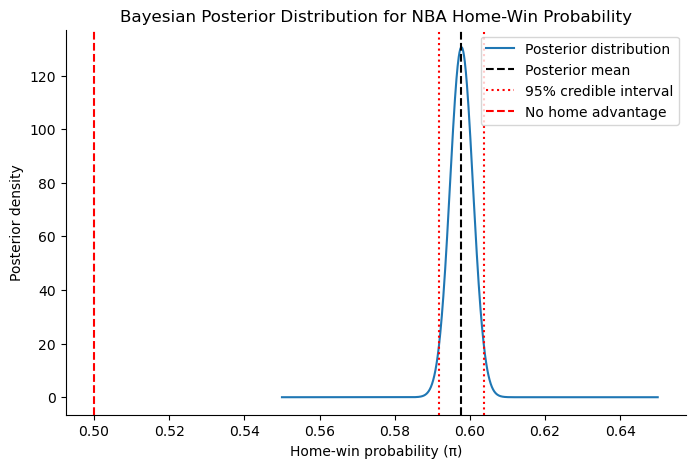

In [20]:
# posterior distribution
x = np.linspace(0.55, 0.65, 1000)
posterior_density = beta.pdf(x, alpha_post, beta_post)

plt.figure(figsize=(8, 5))
plt.plot(x, posterior_density, label="Posterior distribution") # distribution found 
plt.axvline(posterior_mean, linestyle="--", label="Posterior mean", color='black') # wins / total
# quantiles:
plt.axvline(credible_interval[0], linestyle=":", label="95% credible interval", color='red') # 0.25
plt.axvline(credible_interval[1], linestyle=":", color='red') # 0.75

plt.axvline(0.5, linestyle="--", label="No home advantage", color='red')

# icky spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlabel("Home-win probability (π)")
plt.ylabel("Posterior density")
plt.title("Bayesian Posterior Distribution for NBA Home-Win Probability")
plt.legend()
plt.show()

For the Bayesian analysis, we modeled each regular season NBA game as a Bernoulli trial where a home win equals 1 and a home loss equals 0. The unknown parameter π represents the true long-run probability that the home team wins.

We used a Beta(1,1) prior model with a uniform prior and represents limited prior knowledge about the value of π. After observing the data, the posterior distribution was updated using the number of home wins and losses (adding past real wins to the alpha and beta priors of 1 and 1).

The posterior mean (around 0.598) was approximately equal to the frequentist estimate, and the 95% credible interval (around (0.592, 0.604)) was very close to the frequentist confidence interval. This shows that the large sample size of the data dominates the weak prior.

Both frequentist and Naive analysis approaches support the conclusion that NBA teams have historically had a home-court advantage. This agreement indicates that the conclusion is robust and not sensitive to separate modeling assumptions.

### Posterior Predicting

In [21]:
# posterior predictive: simulate future games
simulated_pi = beta.rvs(alpha_post, beta_post, size=10000) # means Random Variantes in sampling (rvs) - randomly generate beta distribution points
predicted_games = np.random.binomial(1, simulated_pi) # random samples from binomial distribution in simulated_pi (the simulated games)

print(f"Predicted home win rate (simulation): {predicted_games.mean()}") # proportion of wins on games sampled

Predicted home win rate (simulation): 0.5966


Using the posterior, we simulated future games based on the current games dataset and found that the predicted home-win rate reinforces our inference section above; the predicted rate of winning simulated games is around that 0.60, which is close to the pi estimate of 0.598 from the data from the inference section.

### Results 

**Posterior Summary:** The posterior distribution for the home-win probability is Beta(15396, 10360), with a posterior mean of 0.5978. The 95% credible interval is (0.592, 0.604), indicating that the true home-win probability is tightly concentrated around 0.60. The posterior probability that π > 0.5 is effectively 1, providing strong evidence of a home-court advantage.

**Interpretation:** In the Bayesian framework, we interpret the credible interval as the range in which the true home-win probability lies with 95% probability, given the observed data and prior. Since the entire interval lies well above 0.5 (0.592, 0.604), this indicates strong evidence that home teams win more often than away teams. Additionally, the posterior distribution is highly concentrated, reflecting low uncertainty due to the large sample size. These results closely align with the frequentist findings in section 3. This suggests that the conclusion of a home-court advantage is robust across different statistical approaches like frequentist vs Bayesian. The credible interval closely matches the frequentist confidence interval, reflecting the large sample size,=.

**Comparison to Frequentist Results:** These Bayesian results closely match the frequentist results from Section 3, as mentioned in interpretation. The posterior mean is almost the same as the maximum likelihood estimator (MLE), and the credible interval is nearly identical to the confidence interval. This agreement occurs because the dataset is large on NBA games, so the weak Beta(1,1) with alpha as 1 and Beta as 1, prior has very little influence on the posterior. Therefore, both approaches lead to the same conclusion, which is that the true home-win probability is meaningfully above 0.5.

# 5 - Resampling and Simulation

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

**Parameter of Interest:** π = the true long-run probability that the home team wins an NBA game

**Estimator:** p̂ = (number of home wins) / (total number of games)

NOTE: This section quantifies the variability of p̂ with uncertainty attributed to season-scoped results.

### Data Prep

In [22]:
np.random.seed(42) # for reproducibility

reg = final_game_df[final_game_df['season_type'] == 'Regular Season'].copy()

reg['home_win'] = (reg['wl_home'] == 'W').astype(int)
reg['pt_diff']  = reg['pts_home'] - reg['pts_away']
reg['season_year'] = reg['season_id'].astype(str).str[-4:].astype(int)

#setting n
n = len(reg)
#summing number of wins
n_wins = reg['home_win'].sum()
#calculating p hat
p_hat  = n_wins / n
#getting base stats
outcomes = reg['home_win'].values
pt_diffs = reg['pt_diff'].values
fg_pcts  = reg['fg_pct_home'].values

### Bootstrap: Home-Win Probability 

We draw B = 10,000 bootstrap samples (with replacement, same size as original) from the observed win/loss outcomes.

For each, we compute p̂*. The percentile method gives a 95% CI as the 2.5th and 97.5th percentiles of the bootstrap distribution.

In [23]:
# Bootstrap CI for home-win probability
n_boot = 10000
boot_props = np.zeros(n_boot)
for i in range(n_boot):
    #resample with replacement from original wins/losses
    boot_sample = np.random.choice([1, 0], size=n,
                                    p=[p_hat, 1 - p_hat], replace=True)
    boot_props[i] = boot_sample.mean()

#95% bootstrap CI
boot_lo = np.percentile(boot_props, 2.5)
boot_hi = np.percentile(boot_props, 97.5)
#results
print(f'Bootstrap 95% CI: ({boot_lo:.6f}, {boot_hi:.6f})')

#boot standard error
boot_se = np.std(boot_props)

Bootstrap 95% CI: (0.591714, 0.603867)


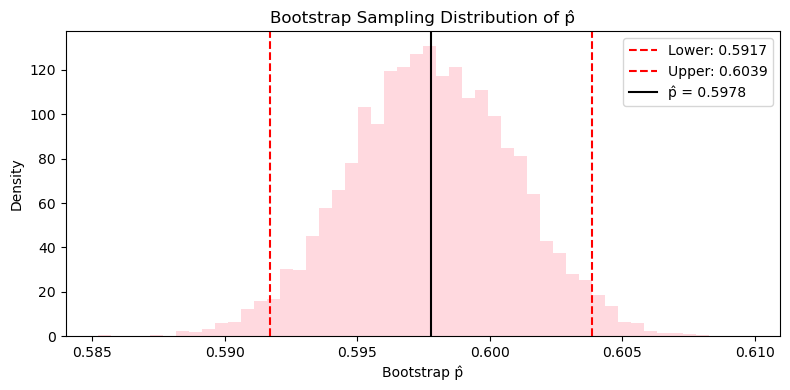

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(boot_props, bins=50, color='pink', alpha=0.6, density=True)
ax.axvline(boot_lo, color='red', ls='--', lw=1.5, label=f'Lower: {boot_lo:.4f}')
ax.axvline(boot_hi, color='red', ls='--', lw=1.5, label=f'Upper: {boot_hi:.4f}')
ax.axvline(p_hat,   color='black', ls='-', lw=1.5, label=f'p̂ = {p_hat:.4f}')

ax.set_xlabel('Bootstrap p̂')
ax.set_ylabel('Density')
ax.set_title('Bootstrap Sampling Distribution of p̂')
ax.legend()
plt.tight_layout()
plt.show()

### Monte Carlo Simulation

**Simulating a Full NBA Season** 
An NBA team plays 82 games per season (41 home, 41 away). Given our estimate:

* P(win at home) = p̂ = 0.5993
* P(win away) ~ 1 − p̂ = 0.4007
We simulate 10,000 seasons to estimate the distribution of total wins.

In [25]:
#use observed home-win rate
p_home = p_hat
#away win rate is the complement
p_away = 1 - p_hat
#number of simulated seasons and games per season
N_sim = 10_000
home_games = 41
away_games = 41

#simulate home and away wins separately, then combine
sim_home_wins  = np.random.binomial(n=home_games, p=p_home, size=N_sim)
sim_away_wins  = np.random.binomial(n=away_games, p=p_away, size=N_sim)
sim_total_wins = sim_home_wins + sim_away_wins

#summarize simulated seasons
expected_wins = sim_total_wins.mean()
ci_80 = (np.percentile(sim_total_wins, 10), np.percentile(sim_total_wins, 90))
ci_95 = (np.percentile(sim_total_wins, 2.5), np.percentile(sim_total_wins, 97.5))

print(f'Expected wins: {expected_wins:.1f}')
print(f'80% interval:  ({ci_80[0]:.0f}, {ci_80[1]:.0f})')
print(f'95% interval:  ({ci_95[0]:.0f}, {ci_95[1]:.0f})')

#theoretical check using binomial mean/variance formulas
theory_mean= 41*p_home + 41*p_away
theory_sd= np.sqrt(41*p_home*(1-p_home) + 41*p_away*(1-p_away))
#printing results
print(f'Theoretical mean: {theory_mean:.2f}  (simulated: {expected_wins:.2f})')
print(f'Theoretical SD:   {theory_sd:.3f}  (simulated: {sim_total_wins.std():.3f})')

Expected wins: 41.0
80% interval:  (35, 47)
95% interval:  (32, 50)
Theoretical mean: 41.00  (simulated: 40.97)
Theoretical SD:   4.440  (simulated: 4.462)


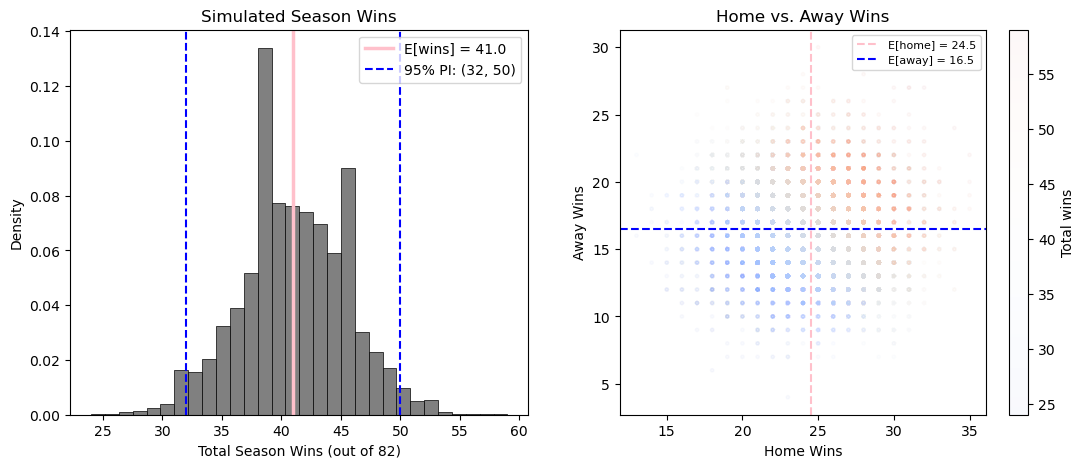

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#season win distribution (left graph)
ax = axes[0]
ax.hist(sim_total_wins, bins=30, color='grey', edgecolor='black', linewidth=0.5, density=True)
ax.axvline(expected_wins, color='pink', lw=2.5, label=f'E[wins] = {expected_wins:.1f}')
ax.axvline(ci_95[0], color='blue', lw=1.5, ls='--', label=f'95% PI: ({ci_95[0]:.0f}, {ci_95[1]:.0f})')
ax.axvline(ci_95[1], color='blue', lw=1.5, ls='--')
ax.set_xlabel('Total Season Wins (out of 82)')
ax.set_ylabel('Density')
ax.set_title('Simulated Season Wins')
ax.legend()
#home vs away wins (right graph)
ax2 = axes[1]
scatter = ax2.scatter(sim_home_wins, sim_away_wins, alpha=0.03, s=6, c=sim_total_wins, cmap='coolwarm')
plt.colorbar(scatter, ax=ax2, label='Total wins')
ax2.axvline(41*p_home, color='pink', lw=1.5, ls='--', label=f'E[home] = {41*p_home:.1f}')
ax2.axhline(41*p_away, color='blue', lw=1.5, ls='--', label=f'E[away] = {41*p_away:.1f}')
ax2.set_xlabel('Home Wins')
ax2.set_ylabel('Away Wins')
ax2.set_title('Home vs. Away Wins')
ax2.legend(fontsize=8)

#plotting
plt.show()

### Monte Carlo cont.

**Simulating the Effect of Losing Home-Court Advantage** 

We use Monte Carlo to answer: How many wins would an average team lose if home-court advantage were eliminated?

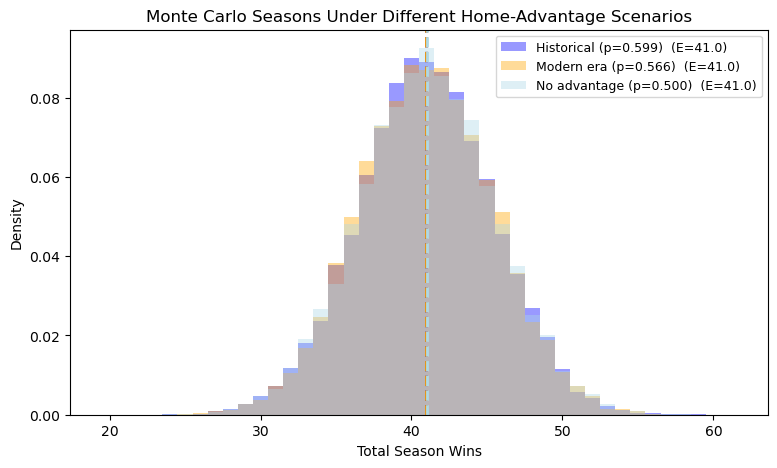

In [27]:
#season win distribution (no home advantage)
# during the 2020 NBA bubble, games were played at a neutral site
# so we model both home and away win probability as 0.5
p_bubble = 0.5
sim_wins_bubble = np.random.binomial(82, p_bubble, size=N_sim)

#Modern
#recent seasons show a weaker home advantage (~56.6% home win rate)
p_modern = 0.566
#home games
sim_home_mod = np.random.binomial(41, p_modern, size=N_sim)
#away agmes (complement)
sim_away_mod = np.random.binomial(41, 1 - p_modern, size=N_sim)
#total wins
sim_wins_mod = sim_home_mod + sim_away_mod

#plot all three cases
# Historical: uses sim_total_wins computed earlier with p_hat
scenarios = {
    #observed p^hat
    'Historical (p=0.599)':sim_total_wins,
    #weaker home effect
    'Modern era (p=0.566)':sim_wins_mod,
    #nuetral game site
    'No advantage (p=0.500)':  sim_wins_bubble
}

#plotting overhapping histograms
fig, ax = plt.subplots(figsize=(9, 5))
palette = ['blue', 'orange', 'lightblue']

for (label, sims), color in zip(scenarios.items(), palette):
    # plot density histogram so all three are on the same scale
    ax.hist(sims, bins=np.arange(19.5, 62.5), density=True,
            alpha=0.4, color=color, label=f'{label}  (E={sims.mean():.1f})')
    # dashed vertical line at the mean for each scenario
    ax.axvline(sims.mean(), color=color, lw=2, ls='--')

ax.set_xlabel('Total Season Wins')
ax.set_ylabel('Density')
ax.set_title('Monte Carlo Seasons Under Different Home-Advantage Scenarios')
ax.legend(fontsize=9)
plt.show()

### Estimator Variability Comparison

We compare bootstrap SE to theoretical SE across all statistics estimated in this project. The ratio boot_SE / theory_SE should be around 1.0 if the CLT approximation holds, and will deviate for statistics without simple asymptotic formulas (like the median).

In [28]:
# bootstrap SE for point differential
boot_diff = np.zeros(n_boot)
for i in range(n_boot):
    boot_sample = np.random.choice(pt_diffs, size=len(pt_diffs), replace=True)
    boot_diff[i] = boot_sample.mean()
se_diff = np.std(boot_diff)

# bootstrap SE for median
boot_med = np.zeros(n_boot)
for i in range(n_boot):
    boot_sample = np.random.choice(pt_diffs, size=len(pt_diffs), replace=True)
    boot_med[i] = np.median(boot_sample)

# bootstrap SE for FG%
boot_fg = np.zeros(n_boot)
for i in range(n_boot):
    boot_sample = np.random.choice(fg_pcts, size=len(fg_pcts), replace=True)
    boot_fg[i] = boot_sample.mean()
se_fg = np.std(boot_fg)

In [29]:
# Collect all SE comparisons
theory_se_prop = np.sqrt(p_hat * (1 - p_hat) / n)
theory_se_diff_mean = np.std(pt_diffs) / np.sqrt(n)
theory_se_fg_mean   = np.std(fg_pcts) / np.sqrt(n)

# Theoretical SE for median ≈ 1/(2*f(m)*sqrt(n)) where f is density at median
from scipy.stats import gaussian_kde
kde = gaussian_kde(pt_diffs)
med_obs = np.median(pt_diffs)
theory_se_med = 1 / (2 * kde(med_obs)[0] * np.sqrt(n))

summary = pd.DataFrame({
    'Statistic':['Home-Win Prob (p̂)', 'Mean Pt Diff', 'Median Pt Diff', 'Mean FG%'],
    'Observed':[p_hat, pt_diffs.mean(), med_obs, fg_pcts.mean()],
    'Bootstrap SE':[boot_se, se_diff, np.std(boot_med), se_fg],
    'Theoretical SE':[theory_se_prop, theory_se_diff_mean, theory_se_med[0] if hasattr(theory_se_med,'__len__') else theory_se_med, theory_se_fg_mean],
})
summary['Ratio (B/T)'] = (summary['Bootstrap SE'] / summary['Theoretical SE']).round(4)
summary[['Observed','Bootstrap SE','Theoretical SE']] = summary[['Observed','Bootstrap SE','Theoretical SE']].round(6)
print(summary.to_string(index=False))

         Statistic  Observed  Bootstrap SE  Theoretical SE  Ratio (B/T)
Home-Win Prob (p̂)  0.597771      0.003096        0.003055       1.0133
      Mean Pt Diff  3.128601      0.085220        0.086005       0.9909
    Median Pt Diff  5.000000      0.038701        0.095687       0.4045
          Mean FG%  0.461654      0.000359        0.000359       1.0004


Ratios close to 1.0 confirm the CLT approximation is valid for these statistics. The median ratio may deviate slightly because its theoretical SE relies on KDE.

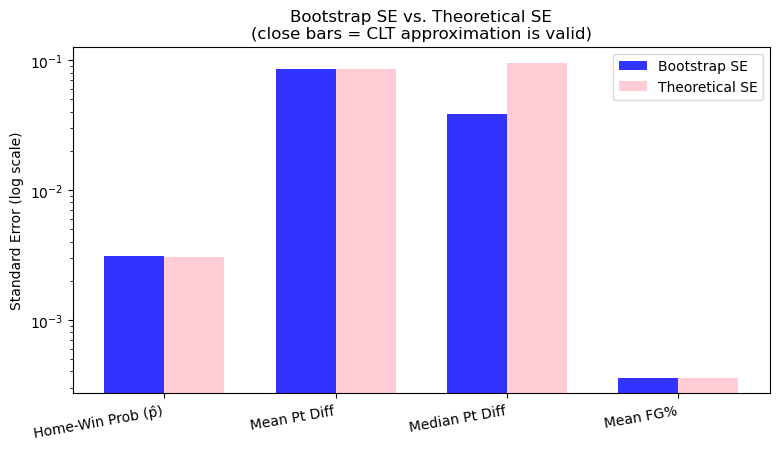

In [30]:
# Visual: Bootstrap SE vs Theoretical SE bar chart
fig, ax = plt.subplots(figsize=(9, 4.5))
stats_labels = summary['Statistic'].tolist()
x = np.arange(len(stats_labels))
width = 0.35
#creating the bar graphs to compare the se of boostrap and theortical
bars1 = ax.bar(x - width/2, summary['Bootstrap SE'],   width, label='Bootstrap SE',    color='blue',   alpha=0.8)
bars2 = ax.bar(x + width/2, summary['Theoretical SE'], width, label='Theoretical SE',  color='pink', alpha=0.8)
#setting x labels and ticks
ax.set_xticks(x)
ax.set_xticklabels(stats_labels, rotation=10, ha='right')
ax.set_ylabel('Standard Error')
ax.set_title('Bootstrap SE vs. Theoretical SE\n(close bars = CLT approximation is valid)')
ax.legend()
#log scale because SEs span different orders of magnitude
ax.set_yscale('log')
ax.set_ylabel('Standard Error (log scale)')
plt.show()

# 6 - Predictive Modeling

**Predictive Question:** Can we predict whether the home team will win an NBA game?

**Target Variable:**  $Y ∈ {0, 1\\}$, where $Y=1$ if the home team wins and $Y=0$ otherwise

**Model:** We fit a logistic regression model to predict the probability that the home team wins based on available features.

**Evaluation Metric:** We initially utilized accuracy_score, precision_score, recall_score, f1_score, and roc_auc_score to evaluate the model on a test set. Then we moved on to more specialized information on the model like model.score and confusion_matrix to visualize results.

### Train/test Split 

Before actually doing the train/test split, we need to clean up the columns to make them more suitable for predictive modeling. First, we need to drop columns that are irrelevant. We are also dropping the points columns because they are direct giveaways to the model for which team won each game.

In [31]:
games = final_game_df.copy() 

# dropping columns that are not needed for predictive modeling
cols_drop = ['min', 'team_abbreviation_home', 'team_abbreviation_away', 'team_nickname_home', 'team_nickname_away', 
             'team_city_name_home', 'team_city_name_away', 'pts_qtr1_home', 'pts_qtr2_home', 'pts_qtr3_home', 'pts_qtr4_home',
             'pts_ot1_home', 'pts_ot2_home', 'pts_ot3_home', 'pts_ot4_home', 'pts_ot5_home', 'pts_ot6_home', 'pts_ot7_home', 
             'pts_ot8_home', 'pts_ot9_home', 'pts_ot10_home', 'pts_qtr1_away', 'pts_qtr2_away', 'pts_qtr3_away', 'pts_qtr4_away', 
             'pts_ot1_away', 'pts_ot2_away', 'pts_ot3_away', 'pts_ot4_away', 'pts_ot5_away', 'pts_ot6_away', 'pts_ot7_away', 
             'pts_ot8_away', 'pts_ot9_away', 'pts_ot10_away', 'largest_lead_home', 'largest_lead_away', 'lead_changes', 'times_tied', 
             'plus_minus_home', 'plus_minus_away', 'video_available_home', 'video_available_away', 'season_type', 'team_rebounds_home',
             'team_rebounds_away', 'team_turnovers_home', 'total_turnovers_home', 'team_turnovers_away', 'total_turnovers_away', 
             'matchup_home', 'matchup_away', 'game_date', 'team_wins_losses_home', 'team_wins_losses_away']
games2 = games.drop(columns=cols_drop)
print(games2.columns)

# change 'wl_home' to be numeric, with W = 1 and L = 0
games2['wl_home'] = games2['wl_home'].map({'W': 1, 'L': 0})

Index(['season_id', 'team_id_home', 'team_name_home', 'game_id', 'wl_home',
       'fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home',
       'fg3_pct_home', 'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home',
       'dreb_home', 'reb_home', 'ast_home', 'stl_home', 'blk_home', 'tov_home',
       'pf_home', 'pts_home', 'team_id_away', 'team_name_away', 'wl_away',
       'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away',
       'fg3_pct_away', 'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away',
       'dreb_away', 'reb_away', 'ast_away', 'stl_away', 'blk_away', 'tov_away',
       'pf_away', 'pts_away', 'game_date_est', 'game_sequence',
       'team_city_home', 'pts_paint_home', 'pts_2nd_chance_home',
       'pts_fb_home', 'pts_off_to_home', 'team_city_away', 'pts_paint_away',
       'pts_2nd_chance_away', 'pts_fb_away', 'pts_off_to_away'],
      dtype='object')


Here, we are creating rolling average columns for the different stats. This means calculating the averages from the previous games, which are then updated after each new game. Doing so helps the model learn about previous patterns for the teams to help predict about the next game.

In [32]:
# columns that need to be transformed into rolling averages 
stat_home_cols = ['fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg3_pct_home', 
             'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home', 
             'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home', 'pts_home',
             'pts_paint_home', 'pts_2nd_chance_home', 'pts_fb_home', 'pts_off_to_home']

stat_away_cols = ['fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away', 'fg3_pct_away',
             'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away',
             'ast_away', 'stl_away', 'blk_away', 'tov_away', 'pf_away', 'pts_away', 
             'pts_paint_away', 'pts_2nd_chance_away', 'pts_fb_away', 'pts_off_to_away']

In [33]:
# for each stat column, create a new column that is the rolling average for the last 10 games
# group by each team_id && drop the original stat column 
# home columns 
for col in stat_home_cols:
    games2[col + '_avg_10'] = games2.groupby('team_id_home')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
    games2 = games2.drop(columns=[col])

# away columns 
for col in stat_away_cols:
    games2[col + '_avg_10'] = games2.groupby('team_id_away')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
    games2 = games2.drop(columns=[col])

# verify new columns
games2.columns 

Index(['season_id', 'team_id_home', 'team_name_home', 'game_id', 'wl_home',
       'team_id_away', 'team_name_away', 'wl_away', 'game_date_est',
       'game_sequence', 'team_city_home', 'team_city_away', 'fgm_home_avg_10',
       'fga_home_avg_10', 'fg_pct_home_avg_10', 'fg3m_home_avg_10',
       'fg3a_home_avg_10', 'fg3_pct_home_avg_10', 'ftm_home_avg_10',
       'fta_home_avg_10', 'ft_pct_home_avg_10', 'oreb_home_avg_10',
       'dreb_home_avg_10', 'reb_home_avg_10', 'ast_home_avg_10',
       'stl_home_avg_10', 'blk_home_avg_10', 'tov_home_avg_10',
       'pf_home_avg_10', 'pts_home_avg_10', 'pts_paint_home_avg_10',
       'pts_2nd_chance_home_avg_10', 'pts_fb_home_avg_10',
       'pts_off_to_home_avg_10', 'fgm_away_avg_10', 'fga_away_avg_10',
       'fg_pct_away_avg_10', 'fg3m_away_avg_10', 'fg3a_away_avg_10',
       'fg3_pct_away_avg_10', 'ftm_away_avg_10', 'fta_away_avg_10',
       'ft_pct_away_avg_10', 'oreb_away_avg_10', 'dreb_away_avg_10',
       'reb_away_avg_10', 'ast_away_a

Creating a new dataframe which is composed of columns that are the difference between the home and away teams' rolling averages is better for the model because it decreases the number of features while keeping the same amount of information.

In [34]:
# create new difference df for the stats 
diff_df = games2[['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']].copy() 

# create difference columns for each above stat
diff_df['fgm_dff'] = games2['fgm_home_avg_10'] - games2['fgm_away_avg_10']
diff_df['fga_diff'] = games2['fga_home_avg_10'] - games2['fga_away_avg_10']
diff_df['fg_pct_diff'] = games2['fg_pct_home_avg_10'] - games2['fg_pct_away_avg_10']
diff_df['fg3m_diff'] = games2['fg3m_home_avg_10'] - games2['fg3m_away_avg_10']
diff_df['fg3a_diff'] = games2['fg3a_home_avg_10'] - games2['fg3a_away_avg_10']
diff_df['fg3_pct_diff'] = games2['fg3_pct_home_avg_10'] - games2['fg3_pct_away_avg_10']
diff_df['ftm_diff'] = games2['ftm_home_avg_10'] - games2['ftm_away_avg_10']
diff_df['fta_diff'] = games2['fta_home_avg_10'] - games2['fta_away_avg_10']
diff_df['ft_pct_diff'] = games2['ft_pct_home_avg_10'] - games2['ft_pct_away_avg_10']
diff_df['oreb_diff'] = games2['oreb_home_avg_10'] - games2['oreb_away_avg_10']
diff_df['dreb_diff'] = games2['dreb_home_avg_10'] - games2['dreb_away_avg_10']
diff_df['reb_diff'] = games2['reb_home_avg_10'] - games2['reb_away_avg_10']
diff_df['ast_diff'] = games2['ast_home_avg_10'] - games2['ast_away_avg_10']
diff_df['stl_diff'] = games2['stl_home_avg_10'] - games2['stl_away_avg_10']
diff_df['blk_diff'] = games2['blk_home_avg_10'] - games2['blk_away_avg_10']
diff_df['tov_diff'] = games2['tov_home_avg_10'] - games2['tov_away_avg_10']
diff_df['pf_diff'] = games2['pf_home_avg_10'] - games2['pf_away_avg_10']
diff_df['pts_diff'] = games2['pts_home_avg_10'] - games2['pts_away_avg_10']
diff_df['pts_paint_diff'] = games2['pts_paint_home_avg_10'] - games2['pts_paint_away_avg_10']
diff_df['pts_2nd_chance_diff'] = games2['pts_2nd_chance_home_avg_10'] - games2['pts_2nd_chance_away_avg_10']
diff_df['pts_fb_diff'] = games2['pts_fb_home_avg_10'] - games2['pts_fb_away_avg_10']
diff_df['pts_off_to_diff'] = games2['pts_off_to_home_avg_10'] - games2['pts_off_to_away_avg_10']

diff_df 

,game_id,team_id_home,team_id_away,game_date_est,wl_home,fgm_dff,fga_diff,fg_pct_diff,fg3m_diff,fg3a_diff,...,ast_diff,stl_diff,blk_diff,tov_diff,pf_diff,pts_diff,pts_paint_diff,pts_2nd_chance_diff,pts_fb_diff,pts_off_to_diff
0,29600012,1610612747,1610612756,1996-11-01 00:00:00,1,-1.000000,-28.000000,0.140000,3.000000,5.000000,...,5.000000,-5.0,4.000000,11.000000,1.000000,14.000000,2.000000,8.000000,-11.000000,NaN
1,29600005,1610612748,1610612737,1996-11-01 00:00:00,1,10.000000,13.000000,0.064000,6.000000,5.000000,...,13.000000,-2.0,-3.000000,-5.000000,5.000000,13.000000,0.000000,-6.000000,-8.000000,NaN
2,29600002,1610612751,1610612739,1996-11-01 00:00:00,0,-11.000000,-14.000000,-0.075000,4.000000,8.000000,...,-3.000000,-3.0,6.000000,7.000000,-5.000000,-13.000000,10.000000,-2.000000,2.000000,NaN
3,29600007,1610612765,1610612754,1996-11-01 00:00:00,1,-1.000000,-6.000000,0.025000,0.000000,-1.000000,...,-7.000000,4.0,-1.000000,1.000000,-8.000000,6.000000,4.000000,-3.000000,-3.000000,NaN
4,29600013,1610612744,1610612746,1996-11-01 00:00:00,0,-14.000000,-11.000000,-0.117000,3.000000,10.000000,...,-1.000000,1.0,1.000000,0.000000,-10.000000,-12.000000,10.000000,10.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28256,42200401,1610612743,1610612748,2023-06-01 00:00:00,1,-0.200000,-1.800000,0.005700,-1.600000,-4.300000,...,0.700000,-0.3,0.600000,0.100000,-0.700000,3.500000,0.400000,-1.200000,5.800000,-5.900000
28257,42200402,1610612743,1610612748,2023-06-04 00:00:00,0,0.700000,-2.700000,0.021500,-1.600000,-4.700000,...,0.800000,0.1,0.000000,0.400000,-1.700000,5.300000,3.000000,-0.400000,7.500000,-6.500000
28258,42200403,1610612748,1610612743,2023-06-07 00:00:00,0,-5.000000,-0.400000,-0.055600,2.700000,7.000000,...,-4.000000,1.1,0.200000,-0.500000,-1.000000,-6.800000,-6.800000,1.700000,-1.100000,0.400000
28259,42200404,1610612748,1610612743,2023-06-09 00:00:00,0,-4.500000,-1.200000,-0.046500,1.100000,3.900000,...,-4.300000,0.2,-0.100000,0.700000,-0.100000,-7.300000,-7.000000,0.300000,-1.000000,-1.000000


Now getting to the train/test split, it is done separating by date. Because the game feature data is dependent on previous games, the rows can't be separated randomly because it would not make sense. Splitting by date, so the training set contains data from before 2018 and the test set contains data from 2018 and after, which is the time we have marked as the "modern era" in our inferential questioning.

In [35]:
# creating train and test set, by date before and after 2018 
train = diff_df[diff_df['game_date_est'] < '2018-01-01']
test = diff_df[diff_df['game_date_est'] >= '2018-01-01']

# creating X as game data and y as win or loss for HOME TEAM
X_train = train.drop(columns=['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']).dropna()
y_train = train.loc[X_train.index, 'wl_home']
X_test = test.drop(columns=['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']).dropna()
y_test = test.loc[X_test.index, 'wl_home']

# verifying that X and y are same shape 
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (20159, 22)
y_train: (20159,)
X_test: (6133, 22)
y_test: (6133,)


### Model Training 

We used a Logistic Regression Model as our predictive model. Before fitting the model, we scaled X_train and X_test to ensure that all features were weighed fairly an so the model didn't misjudge feature importance because of difference in scales for each feature.

In [36]:
# scale the data 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index)

In [37]:
# train logistic regression model and make predictions
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

To evaluate our model, we used accuracy, precision, recall, f1 score, and ROC AUC. We also calculated the training and test accuracy to look at the variance in the model.

In [38]:
# calculate prediction error metrics 
acc = round(accuracy_score(y_test, y_pred), 4)
prec = round(precision_score(y_test, y_pred), 4)
rec = round(recall_score(y_test, y_pred), 4)
f1 = round(f1_score(y_test, y_pred), 4)
auc = round(roc_auc_score(y_test, y_prob), 4)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("ROC AUC:", auc)

Accuracy: 0.7094
Precision: 0.7365
Recall: 0.763
F1 Score: 0.7495
ROC AUC: 0.7714


In [39]:
# calculating training and testing accuracy for the model
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print("Training Accuracy:", round(train_acc, 4))
print("Testing Accuracy:", round(test_acc, 4))

Training Accuracy: 0.7201
Testing Accuracy: 0.7094


This correlation matrix, displayed as a heatmap, shows true negatives, true positives, false negatives, and false positives. These values will be helpful for future analysis.

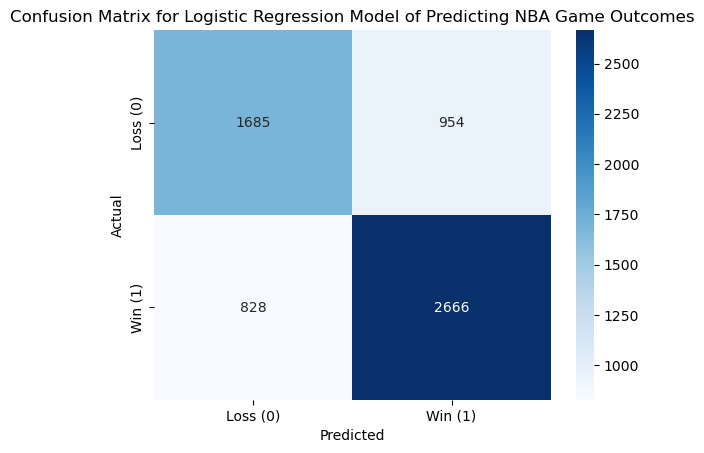

In [40]:
# create correlation matrix and heatmap
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss (0)', 'Win (1)'],
    yticklabels=['Loss (0)', 'Win (1)'])

# predicted values on x axis, actual values on y axis
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression Model of Predicting NBA Game Outcomes')

plt.show()

# 7 - Bias- Variance & Regularization 

**Predictive Question:** Can we predict whether the home team will win an NBA game?

**Target Variable:**  $Y ∈ {0, 1\\}$, where $Y=1$ if the home team wins and $Y=0$ otherwise

**Model:** We compare a standard Logistic Regression model with a Lasso regression model and a Ridge regression model to analyze how model complexity affects performance 

**Evaluation Metric:** We evaluate model performance using metrics such as `accuracy_score`, `precision_score`, `recall_Score`, `f1_score`, and `roc_auc_score`, comparing training and test performance to assess overfitting and generalization. We also reviewed the coefficients of the features that the model utilized. 

### Train/test Split 

*The same cleaning process as in Section 6 is used to create rolling averages and the difference columns.* 

In [41]:
# creating train and test set, by date, using 75% of dates for training  
train = diff_df[diff_df['game_date_est'] < '2018-01-01']
test = diff_df[diff_df['game_date_est'] >= '2018-01-01']

# creating X as game data and y as win or loss for HOME TEAM
X_train = train.drop(columns=['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']).dropna()
y_train = train.loc[X_train.index, 'wl_home']
X_test = test.drop(columns=['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']).dropna()
y_test = test.loc[X_test.index, 'wl_home']

# verifying that X and y are same shape 
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (20159, 22)
y_train: (20159,)
X_test: (6133, 22)
y_test: (6133,)


### Models 

For the comparison of models, we looked at Logistic Regression, Lasso, and Ridge models. Before training the models, we did scale X_train and X_test to ensure the model was treating features fairly.

In [42]:
# scale the data 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index)

In [43]:
# train logistic regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# and Lasso model w C=0.01
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=0.01)
lasso_model.fit(X_train_scaled, y_train)

# and Ridge model 
ridge_model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
ridge_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
# make predictions for all models
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_lasso = lasso_model.predict(X_test_scaled)
y_prob_lasso = lasso_model.predict_proba(X_test_scaled)[:, 1]

y_pred_ridge = ridge_model.predict(X_test_scaled)
y_prob_ridge = ridge_model.predict_proba(X_test_scaled)[:, 1]

After all 3 models were trained and made predictions, we calculated their prediction error metrics to compare the models. All of the models had extremely similar error metrics. The Logistic Regression model slightly outperformed the other two in terms of the accuracy and precision scores, and the Lasso model slightly outperformed the other models in terms of the recall and f1 scores.

In [45]:
# calculate prediction error metrics 
acc_lr = round(accuracy_score(y_test, y_pred_lr), 4)
prec_lr = round(precision_score(y_test, y_pred_lr), 4)
recall_lr = round(recall_score(y_test, y_pred_lr), 4)
f1_lr = round(f1_score(y_test, y_pred_lr), 4)
roc_auc_lr = round(roc_auc_score(y_test, y_prob_lr), 4)

acc_lasso = round(accuracy_score(y_test, y_pred_lasso), 4)
prec_lasso = round(precision_score(y_test, y_pred_lasso), 4)
recall_lasso = round(recall_score(y_test, y_pred_lasso), 4)
f1_lasso = round(f1_score(y_test, y_pred_lasso), 4)
roc_auc_lasso = round(roc_auc_score(y_test, y_prob_lasso), 4)

acc_ridge = round(accuracy_score(y_test, y_pred_ridge), 4)
prec_ridge = round(precision_score(y_test, y_pred_ridge), 4)
recall_ridge = round(recall_score(y_test, y_pred_ridge), 4)
f1_ridge = round(f1_score(y_test, y_pred_ridge), 4)
roc_auc_ridge = round(roc_auc_score(y_test, y_prob_ridge), 4)

print(f'Logistic Regression:\n Accuracy: {acc_lr}\n Precision: {prec_lr}\n Recall: {recall_lr}\n F1 Score: {f1_lr}\n ROC AUC: {roc_auc_lr}')
print(f'\nLasso Regression:\n Accuracy: {acc_lasso}\n Precision: {prec_lasso}\n Recall: {recall_lasso}\n F1 Score: {f1_lasso}\n ROC AUC: {roc_auc_lasso}')
print(f'\nRidge Regression:\n Accuracy: {acc_ridge}\n Precision: {prec_ridge}\n Recall: {recall_ridge}\n F1 Score: {f1_ridge}\n ROC AUC: {roc_auc_ridge}')

Logistic Regression:
 Accuracy: 0.7094
 Precision: 0.7365
 Recall: 0.763
 F1 Score: 0.7495
 ROC AUC: 0.7714

Lasso Regression:
 Accuracy: 0.7093
 Precision: 0.7338
 Recall: 0.7685
 F1 Score: 0.7507
 ROC AUC: 0.7711

Ridge Regression:
 Accuracy: 0.708
 Precision: 0.735
 Recall: 0.7622
 F1 Score: 0.7483
 ROC AUC: 0.7714


Furthermore, looking at the coefficients for each feature generated by the 3 models, there are some differences in which features each model deemed the most important and necessary for prediction. One example is the `pts_diff` feature, which was calculated from the actual point scores from each game. The Logistic Regression and Ridge models had coefficients of 0.329 and 0.447 respectively, whereas Lasso had decreased its coefficient fully down to 0.0.

In [46]:
coef_lr = pd.Series(lr_model.coef_[0], index=X_train_scaled.columns)
coef_lasso = pd.Series(lasso_model.coef_[0], index=X_train_scaled.columns)
coef_ridge = pd.Series(ridge_model.coef_[0], index=X_train_scaled.columns)

comparison = pd.DataFrame({
    "Logistic": coef_lr,
    "Lasso": coef_lasso,
    "Ridge": coef_ridge,
})

print("Coefficient Comparison (sorted by absolute value of Lasso coefficients):\n")
print(comparison.sort_values(by="Lasso", key=abs, ascending=True))

Coefficient Comparison (sorted by absolute value of Lasso coefficients):

                     Logistic     Lasso     Ridge
fgm_dff              0.136910  0.000000  0.143543
pts_2nd_chance_diff -0.009587  0.000000 -0.009997
pts_diff             0.329368  0.000000  0.446847
oreb_diff            0.268176  0.000000  0.268658
fta_diff            -0.308561  0.000000 -0.266439
pts_off_to_diff      0.016634  0.000000  0.016164
fg3a_diff           -0.130506  0.000000 -0.128992
dreb_diff            0.273777  0.017625  0.273383
pts_fb_diff         -0.058936 -0.034032 -0.059279
pf_diff             -0.047644 -0.038573 -0.047475
blk_diff             0.079000  0.059728  0.079137
ftm_diff             0.220523  0.062214  0.122021
fg3_pct_diff         0.006038  0.065886  0.007686
ast_diff             0.120387  0.096341  0.120484
pts_paint_diff      -0.098717 -0.099231 -0.098805
ft_pct_diff          0.017632  0.099881  0.034445
fg3m_diff            0.318270  0.224301  0.277722
stl_diff             0.389

**Bias-Variance Explanation:** The unregularized model may achieve strong performance on the training data but risks overfitting, leading to higher variance and reduced performance on unseen data. Regularization introduces a penalty that shrinks coefficient values, reducing variance at the cost of slightly increased bias.

**Effect of Regularization:** The regularized model produces more stable and generalizable predictions by preventing large coefficient estimates. This improves performance on the test set, even if training accuracy is slightly lower.

**Result:** In terms of performance, all three models performed similarly with accuracy scores around 0.708 to 0.709 range, ROCs around 0.771, and F1 scores around 0.75. Regularization didn't drastically change performance, neither the L1 or L2.

In terms of accuracy, precision, and ROC, the standard Logistic regression performed the best, by 0.0001 in some cases. Lasso (L1) regularization performed the best in recall and f1 scores. Ridge (L2) regularization performed slightly worse than the other two models in each metric. 

In the end, Logistic regression, which keeps all features, is more prone to higher variance, lasso regression sets many coefficients to 0 and has a lower variance, and ridge regression shrinks coefficients closer to 0 but not to 0 with moderate variance reduction.

# 8 - Inference vs Prediction Comparison

Inference and prediction sections in this project both provided complementary insights on whether an NBA home-court team has an advantage in winning games. The inferential analyses (Sections 2–5) showed that the true home-win probability was around 0.60, with very low uncertainty due to the large sample size from the dataset of past NBA games. Ultimately, both frequentist and Bayesian approaches strongly support the conclusion that a home-court advantage exists in historic NBA games.

* estimators of home-win probabilities (p̂) in each inferential section:
    1. section 2: 0.5995
    2. section 3: 0.5978
    3. section 4: ~ 0.598 (posterior mean)
    4. section 5: 0.5993

Despite the inferential approaches indicating a clear home-court advantage, predictive performance remained limited when forecasting the outcomes of unseen future NBA games. While the estimated value of π (the true long-run probability that the home team wins) suggests that the home team wins more often than away teams, predicting the outcome of individual future games remains challenging. Game-level outcomes were dependent on other factors from players and games, such as team strength, player availability, shooting performance, and matchup dynamics, which are not fully captured by the prediction models.

* testing `accuracy_score` from each prediction section:
    1. section 6: 0.7094
    2. section 7: Logistic Regression (0.7094), Lasso Regression (0.7093), Ridge Regression (0.708)

Ultimately, inference was more useful for understanding overall league-wide trends, while prediction was more useful for forecasting specific future game outcomes. The usefulness of each approach depends on the goal, which is that inference explains the underlying home-court advantage, while prediction attempts to classify individual game outcomes.

Uncertainty was also different in inferential and prediction sections, as the uncertainty for estimating π was very small (for example, there was a 95% confidence interval for π from section 3 was (0.591714, 0.603790), a very narrow range). However, the uncertainty in predicting individual games remained higher in relation due to the inherent variability that sports outcomes maintain.

This project demonstrates that strong inferential conclusions do not necessarily translate into strong predictive performance. In this case, inference was strong while prediction performance remained moderate. This highlights the importance of understanding the difference between inferential and predictive tasks, specifically in distinguishing between understanding a population parameter and predicting future observations.